# 17. 长上下文：位置插值（PI）与 NTK / YaRN —— 手搓

模型预训练有个**最大长度**（MiniMind：`max_position_embeddings=32768`）。推理想处理更长的文本，
RoPE 位置频率要不要改？本讲回答这个问题。

- **外推（extrapolation）**：直接用预训练频率跑更长位置 → 高频维度在长位置"疯狂转圈"，注意力失稳
- **位置插值 PI（Position Interpolation）**：把位置坐标整体压缩（频率 ÷ s）→ 平滑但高频细节丢失
- **NTK-aware（YaRN 核心）**：只缩放低频、保留高频 → 兼顾长距离与局部精度

本讲手搓三种频率表，数值验证"圈数"与 RoPE 相对性。


## 1. RoPE 频率与三种缩放

RoPE 旋转角 = 位置 × 频率（第 3 讲）：$\varphi(t,i)=t\cdot\theta_i,\quad \theta_i=\mathrm{base}^{-2i/d}$。

设训练长度 $L$，目标长度 $L'=sL$：

| 方案 | 频率 | 效果 |
|---|---|---|
| 外推 | $\theta_i$（不变） | 高频段圈数随 $t$ 暴涨 → 位置混淆 |
| **PI** | $\theta_i / s$ | 全部频率压缩，目标长度内圈数回到训练时水平 |
| **NTK/YaRN** | $\mathrm{base}'=\mathrm{base}\cdot s^{d/(d-2)}$ | 高频几乎不变（局部精度），低频被插值（长距离） |

圈数（第 $i$ 频段在长度 $L'$ 内的完整旋转数）：$R_i = L'\cdot\theta_i/(2\pi)$——圈数越多，相同位置越"似曾相识"。


In [1]:
import numpy as np
import math

d, base = 8, 1e4                 # 8 维（4 个频段），预训练 base（MiniMind 用 1e6）
L, L_prime, s = 64, 512, 8.0     # 训练长度 64 -> 目标 512，缩放 s = 8

def freqs_of(base_, d):
    """RoPE 频率表：theta_i = base^(-2i/d), i = 0..d/2-1"""
    return np.array([1.0 / (base_ ** (2 * i / d)) for i in range(d // 2)])

f_orig = freqs_of(base, d)                  # 外推：原始频率
f_pi = f_orig / s                           # PI：频率全部 ÷ s
f_ntk = freqs_of(base * (s ** (d / (d - 2))), d)   # NTK：放大 base（等价高频不变低频缩放）

def rounds(freq, length):
    """长度 length 内第 i 频段的完整旋转圈数。"""
    return length * freq / (2 * math.pi)

r_orig, r_pi, r_ntk = rounds(f_orig, L_prime), rounds(f_pi, L_prime), rounds(f_ntk, L_prime)
print('各频段在 512 长度内的旋转圈数（外推 / PI / NTK）：')
for i in range(d // 2):
    print(f'  频段 {i}: 外推 {r_orig[i]:7.2f} | PI {r_pi[i]:7.2f} | NTK {r_ntk[i]:7.2f}')
# 断言：PI 降低高频圈数；NTK 高频保持、低频降低
assert r_pi[0] < r_orig[0], 'PI 应降低高频圈数'
assert abs(r_ntk[0] - r_orig[0]) < 1e-9, 'NTK 应保留最高频'
assert r_ntk[3] < r_orig[3], 'NTK 应缩放最低频'
print('PI 高频圈数↓（10.2 vs 81.5）; NTK 高频不变、低频↓ ->  PASS')


各频段在 512 长度内的旋转圈数（外推 / PI / NTK）：
  频段 0: 外推   81.49 | PI   10.19 | NTK   81.49
  频段 1: 外推    8.15 | PI    1.02 | NTK    4.07
  频段 2: 外推    0.81 | PI    0.10 | NTK    0.20
  频段 3: 外推    0.08 | PI    0.01 | NTK    0.01
PI 高频圈数↓（10.2 vs 81.5）; NTK 高频不变、低频↓ ->  PASS


In [2]:
# ---- 关键性质：任意频率下 RoPE 仍是"相对位置"编码 ----
def rot_matrix(freq, t):
    """位置 t 的旋转矩阵 [8,8]：每对维度一个 2x2 旋转块。"""
    ang = t * freq                                   # [4]
    R = np.zeros((8, 8))
    for i in range(4):
        c, s_ = math.cos(ang[i]), math.sin(ang[i])
        R[2 * i, 2 * i] = c; R[2 * i, 2 * i + 1] = -s_
        R[2 * i + 1, 2 * i] = s_; R[2 * i + 1, 2 * i + 1] = c
    return R

rng = np.random.default_rng(0)
q = rng.standard_normal(8); k = rng.standard_normal(8)
t, s_ = 100, 340                        # 两个长位置（远超训练长度 64）
# 性质：<R(t)q, R(s)k> == <q, R(s-t)k>（旋转角可加性），用 PI 频率验证
lhs = (rot_matrix(f_pi, t) @ q) @ (rot_matrix(f_pi, s_) @ k)
rhs = q @ (rot_matrix(f_pi, s_ - t) @ k)
err = abs(lhs - rhs)
print(f'RoPE 相对性（PI 频率, 位置 {t} 与 {s_}）：|LHS-RHS| = {err:.2e}')
assert err < 1e-10
print('插值频率下 RoPE 仍是相对位置编码（只依赖相对距离）->  PASS')


RoPE 相对性（PI 频率, 位置 100 与 340）：|LHS-RHS| = 4.44e-16
插值频率下 RoPE 仍是相对位置编码（只依赖相对距离）->  PASS


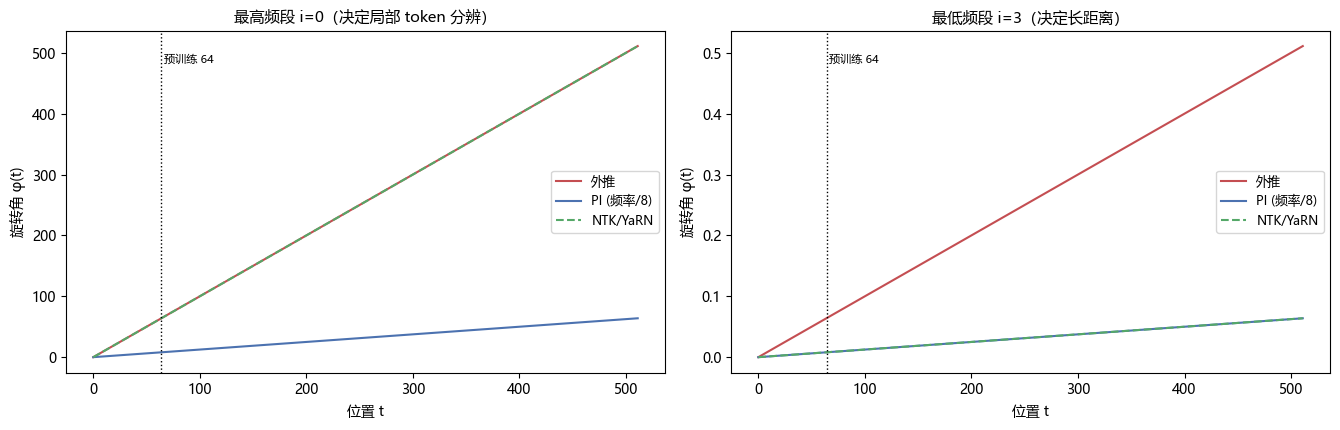

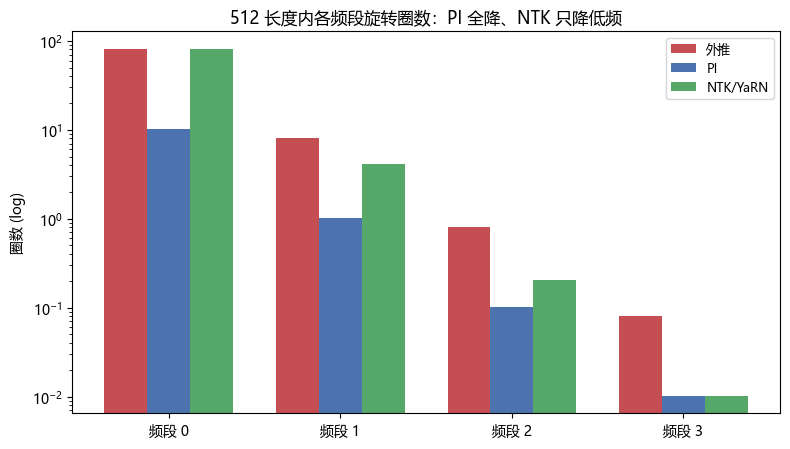

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 图1：旋转角 vs 位置（高频段 i=0 与低频段 i=3）
pos = np.arange(0, 512)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
for ax, i, title in [
    (axes[0], 0, '最高频段 i=0（决定局部 token 分辨）'),
    (axes[1], 3, '最低频段 i=3（决定长距离）')]:
    ax.plot(pos, pos * f_orig[i], label='外推', color='#C44E52')
    ax.plot(pos, pos * f_pi[i], label='PI (频率/8)', color='#4C72B0')
    ax.plot(pos, pos * f_ntk[i], label='NTK/YaRN', color='#55A868', ls='--')
    ax.axvline(64, color='k', ls=':', lw=1); ax.text(66, ax.get_ylim()[1] * 0.9, '预训练 64', fontsize=8)
    ax.set_xlabel('位置 t'); ax.set_ylabel('旋转角 φ(t)'); ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# 图2：512 长度内各频段圈数（外推 vs PI vs NTK）
fig, ax = plt.subplots(figsize=(8, 4.6))
xx = np.arange(4); w = 0.25
ax.bar(xx - w, r_orig, w, label='外推', color='#C44E52')
ax.bar(xx, r_pi, w, label='PI', color='#4C72B0')
ax.bar(xx + w, r_ntk, w, label='NTK/YaRN', color='#55A868')
ax.set_yscale('log')
ax.set_xticks(xx); ax.set_xticklabels([f'频段 {i}' for i in range(4)])
ax.set_ylabel('圈数 (log)')
ax.set_title('512 长度内各频段旋转圈数：PI 全降、NTK 只降低频', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 2. 真实工程对照

| 环节 | 本讲 | minLLM / 生态 |
|---|---|---|
| 预训练长度 | 64（玩具） | `max_position_embeddings=32768`，`rope_theta=1e6` |
| 外推失败点 | 高频圈数 81 圈 | 长于训练长度后注意力分数分布失稳 |
| PI | 频率 ÷ s | HF `rope_scaling={"type":"linear","factor":s}` |
| NTK/YaRN | base × s^(d/(d-2)) | HF `{"type":"dynamic"}` / `yarn`（+温度缩放） |
| 微调适配 | — | 长上下文继续预训练（如 100k→1M 课程学习） |

**工程要点**：直接外推不可靠；PI 简单但损失高频细节；NTK/YaRN 保持局部分辨率；
真正把上下文扩到 1M+（如 DeepSeek）还需要"插值 + 长文本继续预训练 + 注意力结构配合"（如 8 讲的多尺度/稀疏注意力）。


## 总结

- 外推：频率不变，高频圈数随长度暴涨（81.5 圈）→ 位置混淆；
- **PI**：全部频率 ÷ s，圈数回到训练时水平（10.2 圈）→ 平滑但高频细节变少；
- **NTK/YaRN**：只缩低频（高频 81.5 保持、低频从 0.08 降到 0.01）→ 长距离与局部精度兼顾；
- 数值验证：任意缩放频率下 RoPE 依然是"相对位置"编码（相对性 PASS）。
